The purpose of this file is to analyze the .txt files exported by the ATEX software

I want to plot my data in a way that is comparable to how Ernould chapter 4 plots his database

Plots 

When disorientation angle is varied: 
- Fig 2a - Max and Min error of von mises strain versus disorientation 
- Fig 9a  - Max relative error versus disortination, plotted for each of the von mises strain values as a line plot 
- Fig 9c - Relative error versus disorientation for each of the components as a scatter plot 


When strain is varied: 
- Fig 2b - Max and Min error of disorientation angle versus strain 
- Fig 9b - see above 

###  Imports

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import conversions
import os
import ErnouldsMethod
# plt.ion()

## Plotting Functions

### Homography Plotting

In [2]:
def plot_h_components(arrays, x_axis, column_indices, subplotlabels, foldername, plottype = r'\varepsilon_{vm}',
                      style='line', save_name='Relative_Error.png'):
    """Plot selected columns of the 8-component arrays.

    The function always makes three subplots.  If fewer than three
    `column_indices` are provided the remaining axes are turned off.
    This keeps the layout consistent while allowing flexibility.

    Parameters
    ----------
    arrays : list of np.ndarray
        List containing the 8 component arrays, each shape (nRows*nCols,) - is the error for each of the 8 strain components.
    x_axis : np.ndarray
        Values for the x-axis (e.g. ΔPC values).
    column_indices : sequence of int (each value corresponds to a strain, rotation, or homography case)
        Indices of the columns (rows originally) to plot in the subplots.
    subplotlabels : np.ndarray
        Array of labels for each subplot. Needs to be at least as long as the largest index in ``column_indices``.
    foldername : str
        Directory where the figure will be saved.
    plottype : str
        LaTeX math expression describing the secondary quantity being varied
        (e.g. ``"h_{23}"`` or ``"\\Delta\\theta"``).  *Do not* include any
        surrounding dollar signs; they are added automatically by the helper.
        This string is incorporated in the figure and subplot titles so the
        plots indicate which parameter is being stepped.
    style : {'line','marker'}
        Whether to draw line plots or scatter-style markers.
    save_name : str
        File name (without path) under ``foldername`` for saving the figure.
    """
    components = ['h11', 'h12', 'h13', 'h21', 'h22', 'h23', 'h31', 'h32']
    labels = [r'$h_{11}$', r'$h_{12}$', r'$h_{13}$', r'$h_{21}$', r'$h_{22}$',
              r'$h_{23}$', r'$h_{31}$', r'$h_{32}$']
    color_map = {
        'h11': 'mediumseagreen',
        'h12': 'red',
        'h13': 'orange',
        'h21': 'darkgreen',
        'h22': 'gold',
        'h23': 'deepskyblue',
        'h31': 'purple',
        'h32': 'brown',
    }
    linestyle_map = {
        'h11': '-', 'h12': '--', 'h13': '-.', 'h21': ':',
        'h22': '-', 'h23': '--', 'h31': '-.', 'h32': ':'
    }
    marker_map = {
        'h11': 'o', 'h12': 's', 'h13': '^', 'h21': 'D',
        'h22': 'v', 'h23': 'x', 'h31': '+', 'h32': '*'
    }

    # always generate three axes to maintain figure geometry
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    # sanitize the plottype string to avoid double dollar signs
    plottype_clean = plottype.strip('$')

    # iterate only over the requested columns; unused axes will be blanked later
    for ax_idx, col in enumerate(column_indices):
        for comp_idx, comp in enumerate(components):
            y = arrays[comp_idx][:, col]
            if style == 'line':
                plot_kwargs = dict(linestyle=linestyle_map[comp],
                                   color=color_map[comp], linewidth=1.5, alpha=0.8)
            else:
                plot_kwargs = dict(linestyle='None', marker=marker_map[comp],
                                   markersize=5, color=color_map[comp], alpha=0.8)

            if ax_idx == 0:
                ax[ax_idx].plot(x_axis, y, label=labels[comp_idx], **plot_kwargs)
            else:
                ax[ax_idx].plot(x_axis, y, **plot_kwargs)



        ax[ax_idx].set_ylim(-1e1, 1e1)

        ax[ax_idx].set_xlabel("ΔPC (pixels)")
        if ax_idx == 0:
            ax[ax_idx].set_ylabel("Homography Value")
            # baseline value for the varying parameter
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
        else:
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
            ax[ax_idx].set_yticklabels([])

        at = AnchoredText(title,
                          loc='upper left',
                          prop=dict(size=12, weight='bold'),
                          frameon=True)
        at.patch.set_boxstyle("round,pad=0.2")
        ax[ax_idx].add_artist(at)
        ax[ax_idx].grid(which='both', axis='both', linestyle='--', linewidth=0.5)
        ax[ax_idx].grid(which='major', axis='both', linestyle='--', linewidth=1.0)
        # use x_axis values for ticks/labels so they automatically match the data

        xmin = x_axis.min()
        xmax = x_axis.max()

        # make a tick every 0.5 pixels
        ticks = np.arange(xmin, xmax, 1.0)

        ax[ax_idx].set_xticks(ticks)
        ax[ax_idx].set_xticklabels([f"{v:.1f}" for v in ticks])

    # turn off any leftover axes
    for extra in range(len(column_indices), 3):
        ax[extra].axis('off')

    fig.suptitle(rf"Sensitivity Analysis: ${plottype_clean}$", fontsize=16,
                 fontweight='bold', y=0.98)
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 0.90), ncol=9, frameon=False)

    plt.subplots_adjust(top=0.80)
    plt.savefig(os.path.join(foldername, save_name), dpi=300)
    plt.show()

### Strain Plotting

In [3]:
# helper to plot multiple h components with either line or marker styles

def plot_strain_error_components(arrays, x_axis, column_indices, subplotlabels, foldername, plottype = r'\varepsilon_{vm}',
                      style='line', save_name='Relative_Error.png'):
    """Plot selected columns of the 8-component arrays.

    The function always makes three subplots.  If fewer than three
    `column_indices` are provided the remaining axes are turned off.
    This keeps the layout consistent while allowing flexibility.

    Parameters
    ----------
    arrays : list of np.ndarray
        List containing the 8 component arrays, each shape (nRows*nCols,) - is the error for each of the 8 strain components.
    x_axis : np.ndarray
        Values for the x-axis (e.g. ΔPC values).
    column_indices : sequence of int (each value corresponds to a strain, rotation, or homography case)
        Indices of the columns (rows originally) to plot in the subplots.
    subplotlabels : np.ndarray of strings
        Array of labels for each subplot. Needs to be at least as long as the largest index in ``column_indices``.
    foldername : str
        Directory where the figure will be saved.
    plottype : str
        LaTeX math expression describing the secondary quantity being varied
        (e.g. ``"h_{23}"`` or ``"\\Delta\\theta"``).  *Do not* include any
        surrounding dollar signs; they are added automatically by the helper.
        This string is incorporated in the figure and subplot titles so the
        plots indicate which parameter is being stepped.
    style : {'line','marker'}
        Whether to draw line plots or scatter-style markers.
    save_name : str
        File name (without path) under ``foldername`` for saving the figure.
    """
    components = ['e11', 'e12', 'e13', 'e22', 'e23', 'w32', 'w13', 'w21']
    labels = [r'$\varepsilon_{11}$', r'$\varepsilon_{12}$', r'$\varepsilon_{13}$', r'$\varepsilon_{22}$', r'$\varepsilon_{23}$',
              r'$\omega_{23}$', r'$\omega_{13}$', r'$\omega_{21}$'] #the labels for the components you want to plot
    color_map = {
        'e11': 'mediumseagreen',
        'e12': 'red',
        'e13': 'orange',
        'e22': 'darkgreen',
        'e23': 'gold',
        'w32': 'deepskyblue',
        'w13': 'purple',
        'w21': 'brown',
    }
    linestyle_map = {
        'e11': '-', 'e12': '--', 'e13': '-.', 'e22': ':',
        'e23': '-', 'w32': '--', 'w13': '-.', 'w21': ':'
    }
    marker_map = {
        'e11': 'o', 'e12': 's', 'e13': '^', 'e22': 'D',
        'e23': 'v', 'w32': 'x', 'w13': '+', 'w21': '*'
    }

    # always generate three axes to maintain figure geometry
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    # sanitize the plottype string to avoid double dollar signs
    plottype_clean = plottype.strip('$')

    # iterate only over the requested columns; unused axes will be blanked later
    for ax_idx, col in enumerate(column_indices):
        for comp_idx, comp in enumerate(components):
            y = arrays[comp_idx][:, col]
            if style == 'line':
                plot_kwargs = dict(linestyle=linestyle_map[comp],
                                   color=color_map[comp], linewidth=1.5, alpha=0.8)
            else:
                plot_kwargs = dict(linestyle='None', marker=marker_map[comp],
                                   markersize=5, color=color_map[comp], alpha=0.8)

            if ax_idx == 0:
                ax[ax_idx].plot(x_axis, y, label=labels[comp_idx], **plot_kwargs)
            else:
                ax[ax_idx].plot(x_axis, y, **plot_kwargs)

            ax[ax_idx].set_yscale('log')

        ax[ax_idx].set_ylim(1e-7, 1e-1)

        ax[ax_idx].set_xlabel("ΔPC (pixels)")
        if ax_idx == 0:
            ax[ax_idx].set_ylabel("Absolute Error of Strain Components")
            # baseline value for the varying parameter
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
        else:
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
            ax[ax_idx].set_yticklabels([])

        at = AnchoredText(title,
                          loc='upper left',
                          prop=dict(size=12, weight='bold'),
                          frameon=True)
        at.patch.set_boxstyle("round,pad=0.2")
        ax[ax_idx].add_artist(at)
        ax[ax_idx].grid(which='both', axis='both', linestyle='--', linewidth=0.5)
        ax[ax_idx].grid(which='major', axis='both', linestyle='--', linewidth=1.0)
        # use x_axis values for ticks/labels so they automatically match the data

        xmin = x_axis.min()
        xmax = x_axis.max()

        # make a tick every 0.5 pixels
        ticks = np.arange(xmin, xmax, 1.0)

        ax[ax_idx].set_xticks(ticks)
        ax[ax_idx].set_xticklabels([f"{v:.1f}" for v in ticks])

    # turn off any leftover axes
    for extra in range(len(column_indices), 3):
        ax[extra].axis('off')

    fig.suptitle(rf"Sensitivity Analysis: ${plottype_clean}$", fontsize=16,
                 fontweight='bold', y=0.98)
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 0.90), ncol=9, frameon=False)

    plt.subplots_adjust(top=0.80)
    plt.savefig(os.path.join(foldername, save_name), dpi=300)
    plt.show()


### Backcorrected Strain Plotting

In [4]:
def plot_strain_backcorrected_error_components(arrays, x_axis, column_indices, subplotlabels, foldername, plottype = r'\varepsilon_{vm}',
                      style='line', save_name='Backcorrected_Relative_Error.png'):
    """Plot selected columns of the 8-component arrays.

    The function always makes three subplots.  If fewer than three
    `column_indices` are provided the remaining axes are turned off.
    This keeps the layout consistent while allowing flexibility.

    Parameters
    ----------
    arrays : list of np.ndarray
        List containing the 8 component arrays, each shape (nRows*nCols,) - is the error for each of the 8 strain components.
    x_axis : np.ndarray
        Values for the x-axis (e.g. ΔPC values).
    column_indices : sequence of int (each value corresponds to a strain, rotation, or homography case)
        Indices of the columns (rows originally) to plot in the subplots.
    subplotlabels : np.ndarray
        Array of labels for each subplot. Needs to be at least as long as the largest index in ``column_indices``.
    foldername : str
        Directory where the figure will be saved.
    plottype : str
        LaTeX math expression describing the secondary quantity being varied
        (e.g. ``"h_{23}"`` or ``"\\Delta\\theta"``).  *Do not* include any
        surrounding dollar signs; they are added automatically by the helper.
        This string is incorporated in the figure and subplot titles so the
        plots indicate which parameter is being stepped.
    style : {'line','marker'}
        Whether to draw line plots or scatter-style markers.
    save_name : str
        File name (without path) under ``foldername`` for saving the figure.
    """
    components = ['e11', 'e12', 'e13', 'e22', 'e23', 'w32', 'w13', 'w21']
    labels = [r'$\varepsilon_{11}$', r'$\varepsilon_{12}$', r'$\varepsilon_{13}$', r'$\varepsilon_{22}$', r'$\varepsilon_{23}$',
              r'$\omega_{23}$', r'$\omega_{13}$', r'$\omega_{21}$'] #the labels for the components you want to plot
    color_map = {
        'e11': 'mediumseagreen',
        'e12': 'red',
        'e13': 'orange',
        'e22': 'darkgreen',
        'e23': 'gold',
        'w32': 'deepskyblue',
        'w13': 'purple',
        'w21': 'brown',
    }
    linestyle_map = {
        'e11': '-', 'e12': '--', 'e13': '-.', 'e22': ':',
        'e23': '-', 'w32': '--', 'w13': '-.', 'w21': ':'
    }
    marker_map = {
        'e11': 'o', 'e12': 's', 'e13': '^', 'e22': 'D',
        'e23': 'v', 'w32': 'x', 'w13': '+', 'w21': '*'
    }

    # always generate three axes to maintain figure geometry
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    # sanitize the plottype string to avoid double dollar signs
    plottype_clean = plottype.strip('$')

    # iterate only over the requested columns; unused axes will be blanked later
    for ax_idx, col in enumerate(column_indices):
        for comp_idx, comp in enumerate(components):
            y = arrays[comp_idx][:, col]
            if style == 'line':
                plot_kwargs = dict(linestyle=linestyle_map[comp],
                                   color=color_map[comp], linewidth=1.5, alpha=0.8)
            else:
                plot_kwargs = dict(linestyle='None', marker=marker_map[comp],
                                   markersize=5, color=color_map[comp], alpha=0.8)

            if ax_idx == 0:
                ax[ax_idx].plot(x_axis, y, label=labels[comp_idx], **plot_kwargs)
            else:
                ax[ax_idx].plot(x_axis, y, **plot_kwargs)

            ax[ax_idx].set_yscale('log')

        ax[ax_idx].set_ylim(1e-7, 1e-1)

        ax[ax_idx].set_xlabel("ΔPC (pixels)")
        if ax_idx == 0:
            ax[ax_idx].set_ylabel("Absolute Error of Strain Components")
            # baseline value for the varying parameter
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
        else:
            val = subplotlabels[column_indices[ax_idx]]
            title = rf"${plottype_clean} = {val}$"
            ax[ax_idx].set_yticklabels([])

        at = AnchoredText(title,
                          loc='upper left',
                          prop=dict(size=12, weight='bold'),
                          frameon=True)
        at.patch.set_boxstyle("round,pad=0.2")
        ax[ax_idx].add_artist(at)
        ax[ax_idx].grid(which='both', axis='both', linestyle='--', linewidth=0.5)
        ax[ax_idx].grid(which='major', axis='both', linestyle='--', linewidth=1.0)
        # use x_axis values for ticks/labels so they automatically match the data

        xmin = x_axis.min()
        xmax = x_axis.max()

        # make a tick every 0.5 pixels
        ticks = np.arange(xmin, xmax, 0.5)

        ax[ax_idx].set_xticks(ticks)
        ax[ax_idx].set_xticklabels([f"{v:.1f}" for v in ticks])

    # turn off any leftover axes
    for extra in range(len(column_indices), 3):
        ax[extra].axis('off')

    fig.suptitle(rf"Backcorrected Strain Analysis: ${plottype_clean}$", fontsize=16,
                 fontweight='bold', y=0.98)
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 0.90), ncol=9, frameon=False)

    plt.subplots_adjust(top=0.80)
    plt.savefig(os.path.join(foldername, save_name), dpi=300)
    plt.show()

# Inputs

In [5]:
#EMEBSD version 
#file that contains all of the deformation gradient data exported from Al_results visulalization
filename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/PCAnalysis/PCx_allcases_nogblur_EBSDtorch_Mar042026_Mar42026_npyfiles/PCx_allcases_nogblur_EBSDtorch_Mar042026_homographies_Mar42026.npy'

#the true values of strain and rotation 

Testcasesfilename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/Inputs/PC_Sensitivity.csv'

x_axis = np.arange(-2.0, 2.0 + 0.1, 0.1)
#x_axis = np.arange(-2.0, 2.0 + 0.1, 0.1)

#How many Rows and Columns were in the original EBSD scan?
Rows = len(x_axis)
Columns = 12

#---------------------- Plotting parameters --------------

#what columns would you like to plot and what labels would you like for those columns?

plot_labels = np.array(['5e-4', '2e-3', '5e-3'])
# indices of strain cases to include; None means all
selected_cases_truestrain = np.array([5, 8, 9]) # the cases that you want to plot, corresponding to columns 
selected_cases = selected_cases_truestrain #this is for the up2 file 

#what do the labels correspond to? Are they different values of h23, or different values of rotation, or something else? This will be used in the plot titles and saved figure names.

plot_title = r'\varepsilon_{vm}' # this is the quantity that is being stepped in the sensitivity analysis, e.g. rotation or h23. It will be used in the plot titles and saved figure names. Do not include any dollar signs; they are added automatically by the helper.

# --------------------------- output parameters ---------------------------


#results folder path
foldername = f'/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/PCAnalysis/PC_allcases_noblur/'

os.makedirs(foldername, exist_ok=True)




# Conversion to Homography to Strain

Convert the calculated homography values to strain and rotation using conversions, Note that I am currently converting all of the h values, I havent yet selected values. 

In [6]:
h = np.load(
        filename
    )
print(h.shape)


#adding in a cropping line here to set very small values to zero for better visualization of the log plots
h[np.abs(h) < 1e-8] = 0.0

#make a copy of h to manipulate
h_calc = h.copy()

#h is in column major order convert h to row major order for comparison
h11 = h[:, 0]
h12 = h[:, 1]
h13 = h[:, 2]
h21 = h[:, 3]
h22 = h[:, 4]
h23 = h[:, 5]
h31 = h[:, 6]
h32 = h[:, 7]

#restack h in row major order
h_calc = np.stack((h11, h12, h13, h21, h22, h23, h31, h32), axis=1)


F = conversions.h2F(h_calc, np.array([0, 0, 800]))

#pring F shape
print(F.shape)
epsilon, omega = conversions.F2strain(F, small_strain= False)
#epsilon_finite, omega_finite = conversions.F2strain(F, small_strain=False)



# save h_calc as a csv file
np.savetxt(os.path.join(foldername, 'h_calc.csv'), h_calc, delimiter=',')

(492, 8)
(492, 3, 3)


In [7]:
print(epsilon.shape)
print(omega.shape)



(492, 3, 3)
(492, 3, 3)


In [8]:

e11 = epsilon[:, 0, 0]
e12 = epsilon[:, 0, 1]
e13 = epsilon[:, 0, 2]
e22 = epsilon[:, 1, 1]
e23 = epsilon[:, 1, 2]
e33 = epsilon[:, 2, 2]
w13 = omega[:, 0, 2]
w21 = omega[:, 1, 0]
w32 = omega[:, 2, 1]

#convert the rotation components to degrees
w13 = np.degrees(w13)
w21 = np.degrees(w21)
w32 = np.degrees(w32)


In [9]:
#reshape all components to Rows x Columns (this is still the full scan)
e11 = e11.reshape((Rows, Columns))
e12 = e12.reshape((Rows, Columns))
e13 = e13.reshape((Rows, Columns))
e22 = e22.reshape((Rows, Columns))
e23 = e23.reshape((Rows, Columns))
e33 = e33.reshape((Rows, Columns))
w13 = w13.reshape((Rows, Columns))
w21 = w21.reshape((Rows, Columns))
w32 = w32.reshape((Rows, Columns))


### Reading in True Strain Values

In [10]:
#note that I only pull in the values that I want to plot

testcases_data = np.genfromtxt(Testcasesfilename, delimiter=',', encoding='utf-8-sig')
# filter the loaded cases if requested
if selected_cases_truestrain is not None:
    testcases_data = testcases_data[selected_cases_truestrain, :]
    print(f"Using {len(selected_cases_truestrain)} selected cases: {selected_cases_truestrain}")

# breaking the testcases data into euler angles and strain/rotation components
w_true = testcases_data[:, 0:3]
e_true = testcases_data[:, 3:]

print(e_true.shape)
print(w_true.shape)
# print the first 5 rows of e_true and w_true
print("First 5 rows of e_true:")
print(e_true[0:5, :])
print("First 5 rows of w_true:")
print(w_true)


Using 3 selected cases: [5 8 9]
(3, 9)
(3, 3)
First 5 rows of e_true:
[[ 0.00017 -0.00023  0.00025 -0.00023 -0.00019  0.0002   0.00025  0.0002
   0.     ]
 [-0.001    0.0006  -0.0011   0.0006   0.0005   0.0009  -0.0011   0.0009
   0.     ]
 [-0.0011   0.0022   0.0024   0.0022   0.0016   0.0025   0.0024   0.0025
   0.     ]]
First 5 rows of w_true:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [11]:
small_strain = False
F_small_strain = np.zeros((e_true.shape[0], 3, 3))

if small_strain:
    for i in range(e_true.shape[0]):
        F_small_strain[i] = ErnouldsMethod.determineF(e_true[i], w_true[i])
    epsilon_true, omega_true = conversions.F2strain(F_small_strain, small_strain=True)
    e_true = epsilon_true.reshape(e_true.shape)
    omega = omega_true

    print(e_true.shape)

    w13_true = omega[:, 0, 2]
    w21_true = omega[:, 1, 0]
    w32_true = omega[:, 2, 1]

    #convert the rotation components to degrees
    w13_true = np.degrees(w13_true)
    w21_true = np.degrees(w21_true)
    w32_true = np.degrees(w32_true)

    #recomine w13, w21, w32 into a single array to match w_true shape
    w_calculated = np.zeros((w13_true.shape[0], 3))
    w_calculated[:, 0] = w32_true
    w_calculated[:, 1] = w21_true
    w_calculated[:, 2] = w13_true
    print(w_calculated.shape)
    w_true = w_calculated

Each row corresponds to a different pattern center


In [12]:
# ------ now I am trimming each of my arrays in peperation of them being plotted, I need to make sure that they all have the same number of cases (columns) so that I can plot them against each other. I will trim them to match the number of cases in e_true, which is determined by the testcases data I loaded in.

# determine the number of strain cases currently available
n_cases = e_true.shape[0]
print(f"Number of strain cases being analysed: {n_cases}")

#now I need to make sure that my e values also correspond to the same cases as my w values, so I need to trim e to match the number of cases in w (which is determined by the testcases data I loaded in)


print(f"Original shape of e components: {e11.shape}, {e12.shape}, {e13.shape}, {e22.shape}, {e23.shape}, {e33.shape}") 
print(f"original shape of h components: {h11.shape}, {h21.shape}, {h32.shape}") 

h11_plotting = h11.copy().reshape((Rows, Columns))
h12_plotting = h12.copy().reshape((Rows, Columns))
h13_plotting = h13.copy().reshape((Rows, Columns))
h21_plotting = h21.copy().reshape((Rows, Columns))
h22_plotting = h22.copy().reshape((Rows, Columns))
h23_plotting = h23.copy().reshape((Rows, Columns))
h31_plotting = h31.copy().reshape((Rows, Columns))
h32_plotting = h32.copy().reshape((Rows, Columns))

if selected_cases is not None:
    e11 = e11[:, selected_cases]
    e12 = e12[:, selected_cases]
    e13 = e13[:, selected_cases]
    e22 = e22[:, selected_cases]
    e23 = e23[:, selected_cases]
    e33 = e33[:, selected_cases]
    w13 = w13[:, selected_cases]
    w21 = w21[:, selected_cases]
    w32 = w32[:, selected_cases]

    h11_plotting = h11_plotting[:, selected_cases]
    h12_plotting = h12_plotting[:, selected_cases]
    h13_plotting = h13_plotting[:, selected_cases]
    h21_plotting = h21_plotting[:, selected_cases]
    h22_plotting = h22_plotting[:, selected_cases]
    h23_plotting = h23_plotting[:, selected_cases]
    h31_plotting = h31_plotting[:, selected_cases]
    h32_plotting = h32_plotting[:, selected_cases]



print(f"Shape of e components after selecting cases: {e11.shape}, {e12.shape}, {e13.shape}, {e22.shape}, {e23.shape}, {e33.shape}")
print(f"Shape of h components after selecting cases: {h11_plotting.shape}, {h21_plotting.shape}, {h32_plotting.shape}")


Number of strain cases being analysed: 3
Original shape of e components: (41, 12), (41, 12), (41, 12), (41, 12), (41, 12), (41, 12)
original shape of h components: (492,), (492,), (492,)
Shape of e components after selecting cases: (41, 3), (41, 3), (41, 3), (41, 3), (41, 3), (41, 3)
Shape of h components after selecting cases: (41, 3), (41, 3), (41, 3)


### Finding Relative Error

In [13]:
print('e_true shape :', e_true.shape)

e11_true = e_true[:, 0]
e12_true = e_true[:, 1]
e13_true = e_true[:, 2]
e22_true = e_true[:, 4]
e_23_true = e_true[:, 5]

w32_true = w_true[:, 0]
w13_true = w_true[:, 1]
w21_true = w_true[:, 2]

with np.printoptions(precision=6, suppress=True):
    print(w32_true)
    print(w32[:3, :])


e_true shape : (3, 9)
[0. 0. 0.]
[[ 0.00001  -0.000019 -0.000077]
 [-0.000017 -0.000041 -0.000088]
 [-0.000033 -0.000056 -0.000102]]


In [14]:
# subtract the true values from the pcx values from each row in e11_pcx to get the error
# e11_true etc. may have length n_cases now
n_cases = e11_true.shape[0]


# Verify true value shapes for broadcasting
assert e11_true.shape == (n_cases,), f"Expected {n_cases} true values for e11, got {e11_true.shape}"
assert e12_true.shape == (n_cases,), f"Expected {n_cases} true values for e12, got {e12_true.shape}"
assert e13_true.shape == (n_cases,), f"Expected {n_cases} true values for e13, got {e13_true.shape}"
assert e22_true.shape == (n_cases,), f"Expected {n_cases} true values for e22, got {e22_true.shape}"
assert e_23_true.shape == (n_cases,), f"Expected {n_cases} true values for e23, got {e_23_true.shape}"
assert w32_true.shape == (n_cases,), f"Expected {n_cases} true values for w32, got {w32_true.shape}"
assert w13_true.shape == (n_cases,), f"Expected {n_cases} true values for w13, got {w13_true.shape}"
assert w21_true.shape == (n_cases,), f"Expected {n_cases} true values for w21, got {w21_true.shape}"

# compute error arrays, broadcasting with dynamic case count
reshape_vals = (1, n_cases)
print (e11_true.shape)
e11_error = np.abs(e11 - e11_true)
e12_error = np.abs(e12 - e12_true)
e13_error = np.abs(e13 - e13_true)
e22_error = np.abs(e22 - e22_true)
e23_error = np.abs(e23 - e_23_true)
w32_error = np.abs(w32 - w32_true)
w13_error = np.abs(w13 - w13_true)
w21_error = np.abs(w21 - w21_true)


(3,)


# Plotting – use helper function instead of manual loops

### Homographies

In [15]:


#need to build the homography arrya 

h_array = [h11_plotting, h12_plotting, h13_plotting, h21_plotting, h21_plotting, h22_plotting, h31_plotting, h32_plotting] 


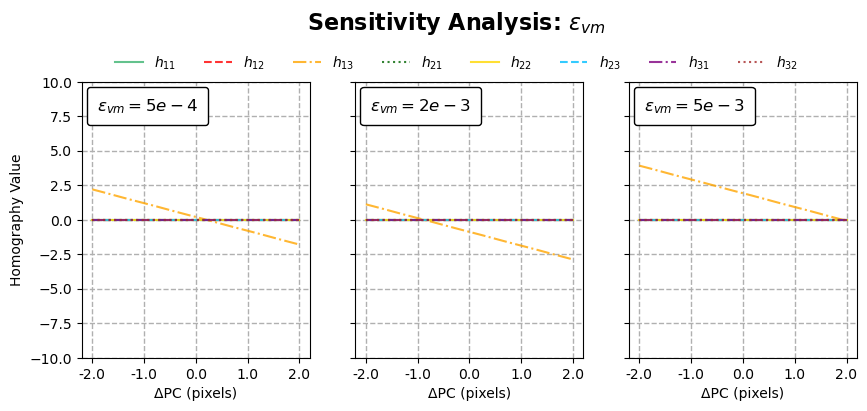

In [16]:
# line‑style version of the component plot
# arrays variable must already be defined in the notebook
columns = [0, 1, 2] #Corresoponds to how many subplots you want 
plot_h_components(h_array, x_axis, columns, plot_labels, foldername,
                  style='line',
                  save_name='Relative_Error_PCx_and_Rotation_lines.png')

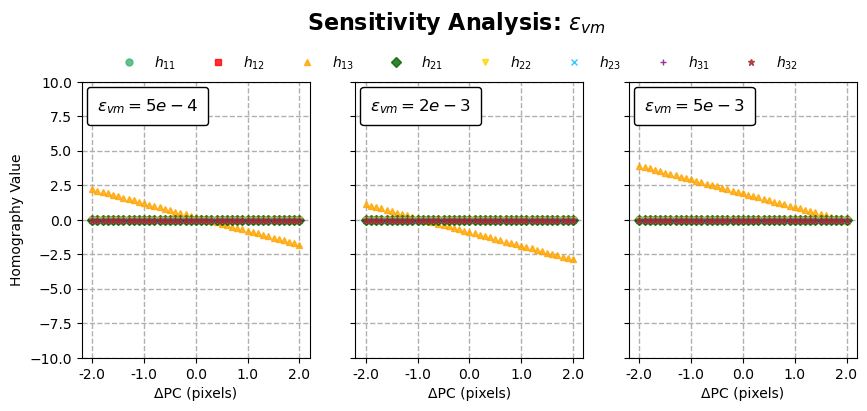

In [17]:
# line‑style version of the component plot
# arrays variable must already be defined in the notebook
plot_h_components(h_array, x_axis, columns, plot_labels, foldername,
                  style='markers',
                  save_name='Relative_Error_PCx_and_Rotation_markers.png')

### Strain

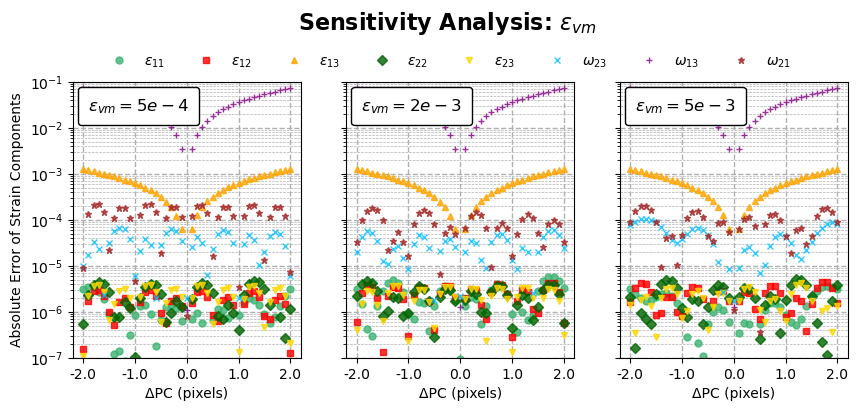

In [18]:
# prepare inputs for the helper
arrays = [e11_error, e12_error, e13_error,
          e22_error, e23_error, 
          w32_error, w13_error, w21_error]
columns = [0, 1, 2]

plot_strain_error_components(arrays, x_axis, columns, plot_labels,
                             foldername,
                             plottype= plot_title,
                             style='marker',
                             save_name='Relative_Error_PCx_and_Rotation_markers.png')

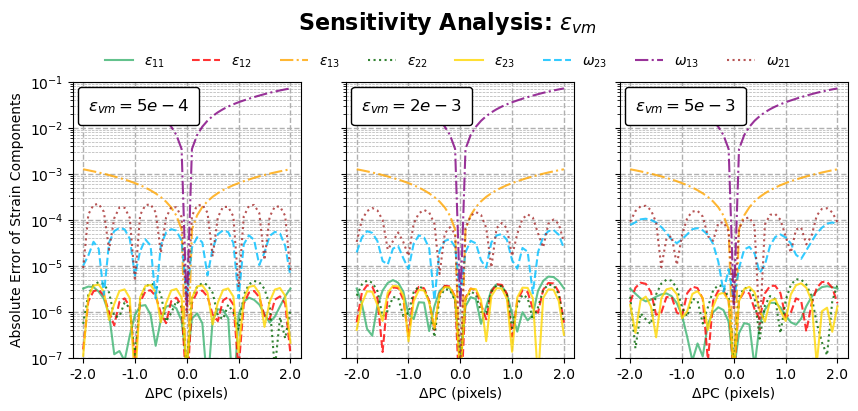

In [19]:
# prepare inputs for the helper
arrays = [e11_error, e12_error, e13_error,
          e22_error, e23_error, 
          w32_error, w13_error, w21_error]
columns = [0, 1, 2]


plot_strain_error_components(arrays, x_axis, columns, plot_labels,
                             foldername,
                             plottype= plot_title,
                             style='line',
                             save_name='Relative_Error_PCx_and_Rotation_line.png')

# Back Correcting For PC deviation

### Step 0: Know PC deviations

In [20]:
delpc = x_axis #the change in the Pc is equal to the x_axis values in the plots

### Step 1: Construct (TS)^(-1)

Note this is simplified by the fact that the x01 and xo2 are 0

PC x

In [21]:
#inputs -----
alpha = np.ones(len(delpc)) # no change in the pc width
delx = 0 - delpc  # the change in pcx
dely = np.zeros(len(delpc))  # no change in pcy
TS_inv_pcx = np.zeros((3,3,len(delpc)))  # preallocate the inverse transformation matrix array

for i in range(len(delpc)):
    TS = np.array(([1/alpha[i], 0, (-1*delx[i]/alpha[i])], [0, 1/alpha[i], (-1*dely[i]/alpha[i])], [0, 0, 1]))  # the three theta values
    #find the inverse of TS
    TS_inv_pcx[:,:,i] = TS




### Step 2: Apply to the optimized homographies

In [22]:
# using h_calc which is the version I copied earlier 
print(TS_inv_pcx.shape)
print(h_calc.shape)

#add an additional column populated by ones to h_calc for the zero deformation case
w_calc = np.hstack((h_calc, np.zeros((h_calc.shape[0], 1))))  

#reshape w_calc to be an array of shape (Rows, Columns, 3, 3)
w_calc = w_calc.reshape(Rows, Columns, 3, 3)

w_corrected = np.zeros_like(w_calc)  # preallocate the corrected array
print (w_calc.shape)
counter = 0
for i in range(Rows):
    for j in range(Columns):
        #pull that row from w_calc and reshape to 3 by 3
        H = w_calc[i, j, :, :]  + np.eye(3)  # shape (3, 3)
        w_corrected[i, j , :, :] =(TS_inv_pcx[:, :, i] @ H ) - np.eye(3)  # initialize with original H
        counter += 1
print(counter)
print(Rows*Columns)
#print(w_corrected[3, 4, :, :])  # print the corrected transformation matrix at row 3, column 4

#reshape w_corrected back to (Rows*Columns, 9)
w_corrected_reshaped = w_corrected.reshape(Rows * Columns, 9)
#drop the last column
h_corrected = w_corrected_reshaped[:, :8]





(3, 3, 41)
(492, 8)
(41, 12, 3, 3)
492
492


Version 2 the modified homography 

In [23]:
pc = np.array([0, 0, 800])

### Step 3: Recalc Strain and Rotation

In [24]:
#h is in column major order convert h to row major order for comparison
h11_corrected = h_corrected[:, 0]
h12_corrected = h_corrected[:, 1]
h13_corrected = h_corrected[:, 2]
h21_corrected = h_corrected[:, 3]
h22_corrected = h_corrected[:, 4]
h23_corrected = h_corrected[:, 5]
h31_corrected = h_corrected[:, 6]
h32_corrected = h_corrected[:, 7]

#restack h in row major order
h_calc = np.stack((h11_corrected, h12_corrected, h13_corrected, h21_corrected, h22_corrected, h23_corrected, h31_corrected, h32_corrected), axis=1)

In [25]:
F_new = conversions.h2F(h_corrected, np.array([0, 0, 800]))

#pring F shape
print(F_new.shape)
epsilon_corrected, omega_corrected = conversions.F2strain(F_new, small_strain=False)

print(epsilon_corrected.shape)



(492, 3, 3)
(492, 3, 3)


### Step 4: New Errors

In [26]:
e11_corrected = epsilon_corrected[:, 0, 0]
e12_corrected = epsilon_corrected[:, 0, 1]
e13_corrected = epsilon_corrected[:, 0, 2]
e22_corrected = epsilon_corrected[:, 1, 1]
e23_corrected = epsilon_corrected[:, 1, 2]
e33_corrected = epsilon_corrected[:, 2, 2]
w13_corrected = omega_corrected[:, 0, 2]
w21_corrected = omega_corrected[:, 1, 0]
w32_corrected = omega_corrected[:, 2, 1]

#convert the rotation components to degrees
w13_corrected = np.degrees(w13_corrected)
w21_corrected = np.degrees(w21_corrected)
w32_corrected = np.degrees(w32_corrected)

In [27]:
#reshape all components to Rows x Columns
e11_corrected = e11_corrected.reshape((Rows, Columns))
e12_corrected = e12_corrected.reshape((Rows, Columns))
e13_corrected = e13_corrected.reshape((Rows, Columns))
e22_corrected = e22_corrected.reshape((Rows, Columns))
e23_corrected = e23_corrected.reshape((Rows, Columns))
e33_corrected = e33_corrected.reshape((Rows, Columns))
w13_corrected = w13_corrected.reshape((Rows, Columns))
w21_corrected = w21_corrected.reshape((Rows, Columns))
w32_corrected = w32_corrected.reshape((Rows, Columns))

In [28]:


if selected_cases is not None:
    e11_corrected = e11_corrected[:, selected_cases]
    e12_corrected = e12_corrected[:, selected_cases]
    e13_corrected = e13_corrected[:, selected_cases]
    e22_corrected = e22_corrected[:, selected_cases]
    e23_corrected = e23_corrected[:, selected_cases]
    e33_corrected = e33_corrected[:, selected_cases]
    w13_corrected = w13_corrected[:, selected_cases]
    w21_corrected = w21_corrected[:, selected_cases]
    w32_corrected = w32_corrected[:, selected_cases]





In [29]:

#subtract the true values from the pcx values from each row in e11_pcx to get the error
# Explicit broadcasting: each row gets the same 12 true values subtracted
e11_pcx_error = np.abs(e11_corrected - e11_true[None, :])
e12_pcx_error = np.abs(e12_corrected - e12_true[None, :])
e13_pcx_error = np.abs(e13_corrected - e13_true[None, :])
e22_pcx_error = np.abs(e22_corrected - e22_true[None, :])
e23_pcx_error = np.abs(e23_corrected - e_23_true[None, :])
w32_pcx_error = np.abs(w32_corrected - w32_true[None, :])
w13_pcx_error = np.abs(w13_corrected - w13_true[None, :])
w21_pcx_error = np.abs(w21_corrected - w21_true[None, :])

# Plotting Corrected Values

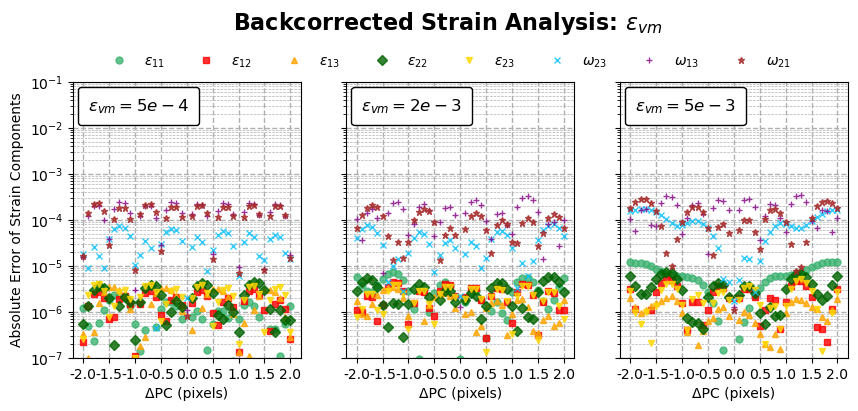

In [30]:
# prepare inputs for the helper
arrays = [e11_pcx_error, e12_pcx_error, e13_pcx_error,
          e22_pcx_error, e23_pcx_error, 
          w32_pcx_error, w13_pcx_error, w21_pcx_error]
columns = [0, 1, 2]
subplotlabels = np.array([0.0, 0.3, 0.5])  # approximate rotation in degrees

plot_strain_backcorrected_error_components(arrays, x_axis, columns, plot_labels,
                             foldername,
                             plottype= plot_title,
                             style='marker',
                             save_name='Backcorrected_Relative_Error_PCx_and_Rotation_markers.png')

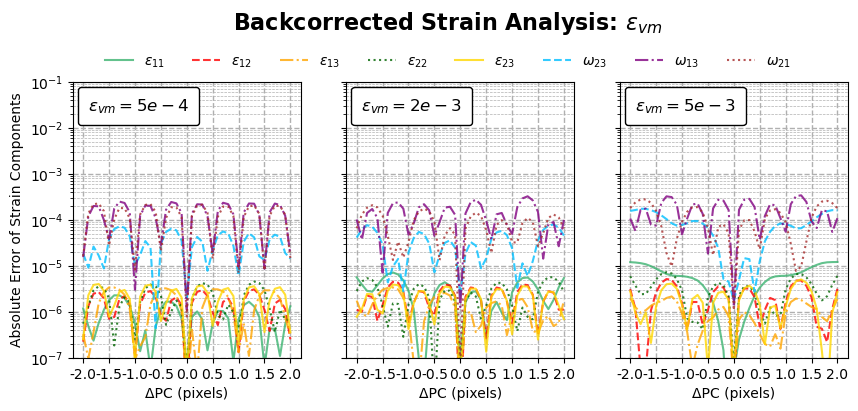

In [31]:
# prepare inputs for the helper
arrays = [e11_pcx_error, e12_pcx_error, e13_pcx_error,
          e22_pcx_error, e23_pcx_error, 
          w32_pcx_error, w13_pcx_error, w21_pcx_error]
columns = [0, 1, 2]
subplotlabels = np.array([0.0, 0.3, 0.5])  # approximate rotation in degrees

plot_strain_backcorrected_error_components(arrays, x_axis, columns, plot_labels,
                             foldername,
                             plottype= plot_title,
                             style='line',
                             save_name='Backcorrected_Relative_Error_PCx_and_Rotation_markers.png')